# Mixed-method example with IBIF and passenger transport

This notebook shows how to use a mixed `edges` method that combines
biosphere-to-technosphere and technosphere-to-technosphere
characterization factors in the same run.

We use the built-in method
`("IBIF", "biodiversity", "all pressures", "vertebrates")`
and compare a balanced sample of non-market passenger-transport activities from the
`ecoinvent-3.12-cutoff` project.

Audience:
- `edges` users who already have a Brightway project with ecoinvent 3.12.

Prerequisites:
- The Brightway project `ecoinvent-3.12-cutoff` must exist locally.
- The ecoinvent database `ecoinvent-3.12-cutoff` must be available in that project.
- The current Python environment must import `edges`, `bw2data`, `pandas`, `numpy`, and `matplotlib`.

Learning goals:
- Run a mixed `EdgeLCIA` method.
- Inspect the `supplier matrix` and `direction` columns in `generate_cf_table()`.
- Aggregate mixed-method results into the three IBIF pressure families:
  emissions, land occupation, and road infrastructure.
- Keep unit differences explicit when comparing direct car transport with
  person-kilometer passenger modes.


## Outline

1. Load the Brightway project and select a balanced passenger-transport sample.
2. Run one mixed-method `EdgeLCIA` calculation and inspect the exported table.
3. Classify supplier rows into IBIF pressure families.
4. Reuse the same `EdgeLCIA` object with `redo_lcia(...)` for several datasets.
5. Plot the contribution split in one integrated transport list, with unit tags kept visible.


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import bw2data

from edges import EdgeLCIA

PROJECT = "ecoinvent-3.12-cutoff"
DATABASE = "ecoinvent-3.12-cutoff"
METHOD = ("IBIF", "biodiversity", "all pressures", "vertebrates")
METHOD_UNIT = "MSA-loss.km2.yr"

ACTIVITY_SPECS = [
    {"label": "Bicycle", "name": "transport, passenger, bicycle", "locations": ["CH"]},
    {"label": "Electric bicycle", "name": "transport, passenger, bicycle, electric", "locations": ["CH"]},
    {"label": "Bus", "name": "transport, passenger, bus, diesel, regular", "locations": ["CH"]},
    {"label": "Coach", "name": "transport, passenger, coach, diesel", "locations": ["CH"]},
    {"label": "Tram", "name": "transport, passenger, tram, electric", "locations": ["CH"]},
    {"label": "Train regional", "name": "transport, passenger, train, electric, regional", "locations": ["CH"]},
    {"label": "Train long-distance", "name": "transport, passenger, train, electric, long-distance", "locations": ["CH"]},
    {"label": "Aircraft short haul", "name": "transport, passenger, aircraft, short haul", "locations": ["GLO"]},
    {"label": "Aircraft long haul", "name": "transport, passenger, aircraft, long haul", "locations": ["GLO"]},
    {"label": "Diesel car", "name": "transport, passenger, car, diesel, small size, EURO 5", "locations": ["RoW"]},
    {"label": "Electric car", "name": "transport, passenger, car, electric", "locations": ["GLO"]},
]

DISPLAY_ORDER = [
    "Bicycle",
    "Electric bicycle",
    "Bus",
    "Coach",
    "Tram",
    "Train regional",
    "Train long-distance",
    "Aircraft short haul",
    "Aircraft long haul",
    "Diesel car",
    "Electric car",
]

SUPPLIER_TYPE_ORDER = [
    "Emissions",
    "Land occupation",
    "Road infrastructure",
]

bw2data.projects.set_current(PROJECT)
db = bw2data.Database(DATABASE)

print(f"Project: {bw2data.projects.current}")
print(f"Database: {DATABASE}")
print(f"Method: {METHOD}")


15:40:48+0200 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.
Project: ecoinvent-3.12-cutoff
Database: ecoinvent-3.12-cutoff
Method: ('IBIF', 'biodiversity', 'all pressures', 'vertebrates')


## Step 1 - Select a balanced sample of passenger-transport activities

We use direct transport activities, not markets. The sample spans light
mobility, road public transport, rail, air transport, and two direct car
datasets.

Most selected datasets use `person kilometer` as their functional unit. The
two direct car activities use `kilometer`, so the final chart keeps them in
the same transport list but labels their functional units explicitly.


In [2]:
activities = {}
rows = []

for spec in ACTIVITY_SPECS:
    matches = [act for act in db if act["name"] == spec["name"]]
    if not matches:
        raise ValueError(f"Could not find activity: {spec['name']}")

    activity = None
    for location in spec["locations"]:
        location_matches = [act for act in matches if act.get("location") == location]
        if location_matches:
            activity = location_matches[0]
            break

    if activity is None:
        available_locations = sorted({act.get("location") for act in matches})
        raise ValueError(
            f"Could not find requested location for {spec['name']}. "
            f"Available locations: {available_locations}"
        )

    activities[spec["label"]] = activity
    rows.append(
        {
            "label": spec["label"],
            "name": activity["name"],
            "reference product": activity.get("reference product"),
            "location": activity.get("location"),
            "unit": activity.get("unit"),
        }
    )

activity_table = pd.DataFrame(rows).set_index("label")
activity_table


,name,reference product,location,unit
label,,,,
Bicycle,"transport, passenger, bicycle","transport, passenger, bicycle",CH,person kilometer
Electric bicycle,"transport, passenger, bicycle, electric","transport, passenger, bicycle, electric",CH,person kilometer
Bus,"transport, passenger, bus, diesel, regular","transport, passenger, bus, diesel, regular",CH,person kilometer
Coach,"transport, passenger, coach, diesel","transport, passenger, coach, diesel",CH,person kilometer
Tram,"transport, passenger, tram, electric","transport, passenger, tram, electric",CH,person kilometer
Train regional,"transport, passenger, train, electric, regional","transport, passenger, train, fleet average",CH,person kilometer
Train long-distance,"transport, passenger, train, electric, long-di...","transport, passenger, train, fleet average",CH,person kilometer
Aircraft short haul,"transport, passenger, aircraft, short haul","transport, passenger, aircraft, short haul",GLO,person kilometer
Aircraft long haul,"transport, passenger, aircraft, long haul","transport, passenger, aircraft, long haul",GLO,person kilometer


## Step 2 - Run one mixed-method `EdgeLCIA` calculation

The IBIF `all pressures` method mixes two directions:

- `biosphere-technosphere` for emissions and land occupation flows
- `technosphere-technosphere` for road infrastructure suppliers

The exported contribution table exposes both via the
`supplier matrix` and `direction` columns.


In [3]:
first_label = next(iter(activities))
first_activity = activities[first_label]

lcia = EdgeLCIA({first_activity: 1}, METHOD)
lcia.lci()
lcia.apply_strategies()
lcia.evaluate_cfs()
lcia.lcia()

first_table = lcia.generate_cf_table(include_unmatched=False)

print(f"{first_label} score: {lcia.score:.6e} {METHOD_UNIT}")
first_table.groupby(["supplier matrix", "direction"])["impact"].sum().sort_values(ascending=False)


/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.43e+12)
  warnings.warn(msg, UmfpackWarning)


Finding direct matches        [1/5]
Resolving aggregate locations [2/5]


IAI Area, Western and Central Europe not found in regex
US-PR not found in regex


Geomatcher: Used 'RU' for 'IAI Area, Russia and Eastern Europe'
Geomatcher: Used 'RU' for 'IAI Area, Russia and Eastern Europe'
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]


IAI Area, Western and Central Europe not found in regex
US-PR not found in regex


Geomatcher: Used 'RU' for 'IAI Area, Russia and Eastern Europe'
Geomatcher: Used 'RU' for 'IAI Area, Russia and Eastern Europe'
Resolving global locations    [5/5]
Fallback follow-up: 17 edge(s) were resolved later; 0 edge(s) remain unmatched.
Bicycle score: 2.853527e-08 MSA-loss.km2.yr


supplier matrix  direction                
technosphere     technosphere-technosphere    2.444539e-08
biosphere        biosphere-technosphere       4.089883e-09
Name: impact, dtype: float64

In [4]:
first_table[
    [
        "supplier matrix",
        "direction",
        "supplier name",
        "supplier categories",
        "supplier location",
        "amount",
        "CF",
        "impact",
    ]
].sort_values("impact", ascending=False).head(12)


,supplier matrix,direction,supplier name,supplier categories,supplier location,amount,CF,impact
20031,technosphere,technosphere-technosphere,road construction,NaN,CH,0.000049,4.450000e-04,2.187531e-08
20034,technosphere,technosphere-technosphere,"road construction, company, internal",NaN,RoW,0.000003,5.243652e-04,1.447742e-09
20033,technosphere,technosphere-technosphere,road construction,NaN,RoW,0.000002,5.243652e-04,1.104658e-09
1411,biosphere,biosphere-technosphere,"Occupation, traffic area, road network","(natural resource, land)",NaN,0.000316,7.610000e-07,2.406211e-10
15837,biosphere,biosphere-technosphere,"Carbon dioxide, fossil","(air, urban air close to ground)",NaN,0.000751,3.090000e-07,2.319517e-10
12019,biosphere,biosphere-technosphere,"Methane, fossil","(air, non-urban air or from high stacks)",NaN,0.000014,9.208200e-06,1.261928e-10
19721,biosphere,biosphere-technosphere,"Carbon dioxide, fossil","(air, non-urban air or from high stacks)",NaN,0.000379,3.090000e-07,1.172484e-10
4069,biosphere,biosphere-technosphere,"Carbon dioxide, fossil","(air,)",NaN,0.000302,3.090000e-07,9.322892e-11
19321,biosphere,biosphere-technosphere,"Carbon dioxide, fossil","(air, non-urban air or from high stacks)",NaN,0.000282,3.090000e-07,8.712823e-11
1018,biosphere,biosphere-technosphere,"Methane, fossil","(air, non-urban air or from high stacks)",NaN,0.000008,9.208200e-06,7.561373e-11


## Step 3 - Collapse mixed-method rows into IBIF pressure families

For this method, the mapping is:

- `technosphere` suppliers -> `Road infrastructure`
- biosphere suppliers in category `("natural resource", "land")`
  -> `Land occupation`
- remaining biosphere suppliers -> `Emissions`

This gives a compact view of what the mixed method is actually
characterizing without losing the distinction between biosphere and
technosphere pressure families.


In [5]:
def is_land_category(value) -> bool:
    if isinstance(value, (tuple, list)):
        lowered = tuple(str(x).lower() for x in value)
        return "natural resource" in lowered and "land" in lowered
    text = str(value).lower()
    return "natural resource" in text and "land" in text


def classify_supplier_type(table: pd.DataFrame) -> pd.DataFrame:
    result = table.copy()
    is_road = result["supplier matrix"].eq("technosphere")
    is_land = (
        result["supplier matrix"].eq("biosphere")
        & result["supplier categories"].apply(is_land_category)
    )
    result["supplier type"] = np.select(
        [is_road, is_land],
        ["Road infrastructure", "Land occupation"],
        default="Emissions",
    )
    return result


classified_first_table = classify_supplier_type(first_table)
classified_first_table.groupby("supplier type")["impact"].sum().reindex(
    SUPPLIER_TYPE_ORDER,
    fill_value=0.0,
)


supplier type
Emissions              3.528147e-09
Land occupation        5.617363e-10
Road infrastructure    2.444539e-08
Name: impact, dtype: float64

## Step 4 - Reuse the same `EdgeLCIA` object across several datasets

Mixed methods are supported by `redo_lcia(...)`, so we can keep the
same object and switch the functional unit for each passenger-transport activity.

We intentionally keep `split_aggregate_consumers=False` here. The
unsplit deterministic table is much smaller, and that is enough for a
supplier-type breakdown. If you want consumer-country expansion for
geographic fallback rows, you can rerun `generate_cf_table()` with
`split_aggregate_consumers=True`.


In [6]:
records = []
detailed_tables = {}
scores = {}

for i, (label, activity) in enumerate(activities.items()):
    if i > 0:
        lcia.redo_lcia({activity: 1})

    table = classify_supplier_type(
        lcia.generate_cf_table(include_unmatched=False)
    )
    detailed_tables[label] = table
    scores[label] = lcia.score

    grouped = (
        table.groupby("supplier type")["impact"]
        .sum()
        .reindex(SUPPLIER_TYPE_ORDER, fill_value=0.0)
    )

    for supplier_type, impact in grouped.items():
        records.append(
            {
                "dataset": label,
                "supplier type": supplier_type,
                "impact": impact,
            }
        )

summary = pd.DataFrame(records)
plot_data = (
    summary.pivot(index="dataset", columns="supplier type", values="impact")
    .reindex(index=DISPLAY_ORDER, columns=SUPPLIER_TYPE_ORDER)
    .fillna(0.0)
    .join(activity_table[["unit", "location"]])
)

plot_data["Total"] = plot_data[SUPPLIER_TYPE_ORDER].sum(axis=1)
plot_data = plot_data.sort_values("Total", ascending=False)
plot_data


/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.43e+12)
  warnings.warn(msg, UmfpackWarning)


Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]


/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.43e+12)
  warnings.warn(msg, UmfpackWarning)


Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]


/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.43e+12)
  warnings.warn(msg, UmfpackWarning)


...

Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]


/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.43e+12)
  warnings.warn(msg, UmfpackWarning)


Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]


/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.43e+12)
  warnings.warn(msg, UmfpackWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.43e+12)
  warnings.warn(msg, UmfpackWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.43e+12)
  warnings.warn(msg, UmfpackWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.43e+12)
  warnings.warn(msg, UmfpackWarning)


,Emissions,Land occupation,Road infrastructure,unit,location,Total
dataset,,,,,,
Electric car,7.795014e-08,9.977307e-09,4.243506e-07,kilometer,GLO,5.122780e-07
Diesel car,8.195178e-08,6.878211e-09,4.201817e-07,kilometer,RoW,5.090117e-07
Bus,3.458617e-08,3.398232e-09,2.084752e-07,person kilometer,CH,2.464596e-07
Coach,1.719078e-08,2.289391e-09,1.435531e-07,person kilometer,CH,1.630332e-07
Aircraft short haul,4.166729e-08,9.634776e-10,2.202431e-09,person kilometer,GLO,4.483320e-08
Electric bicycle,7.193352e-09,1.107809e-09,3.095233e-08,person kilometer,CH,3.925349e-08
Aircraft long haul,3.349385e-08,3.464660e-10,1.560203e-09,person kilometer,GLO,3.540052e-08
Bicycle,3.528147e-09,5.617363e-10,2.444539e-08,person kilometer,CH,2.853527e-08
Train regional,5.629661e-09,4.575462e-09,6.775154e-09,person kilometer,CH,1.698028e-08


## Step 5 - Plot the contribution by supplier type

The chart below sorts transport modes from highest to lowest total IBIF score.
All modes stay in one ranking, while only the direct car rows keep an explicit
`vehicle-km` tag because the remaining datasets are reported per `person-km`.


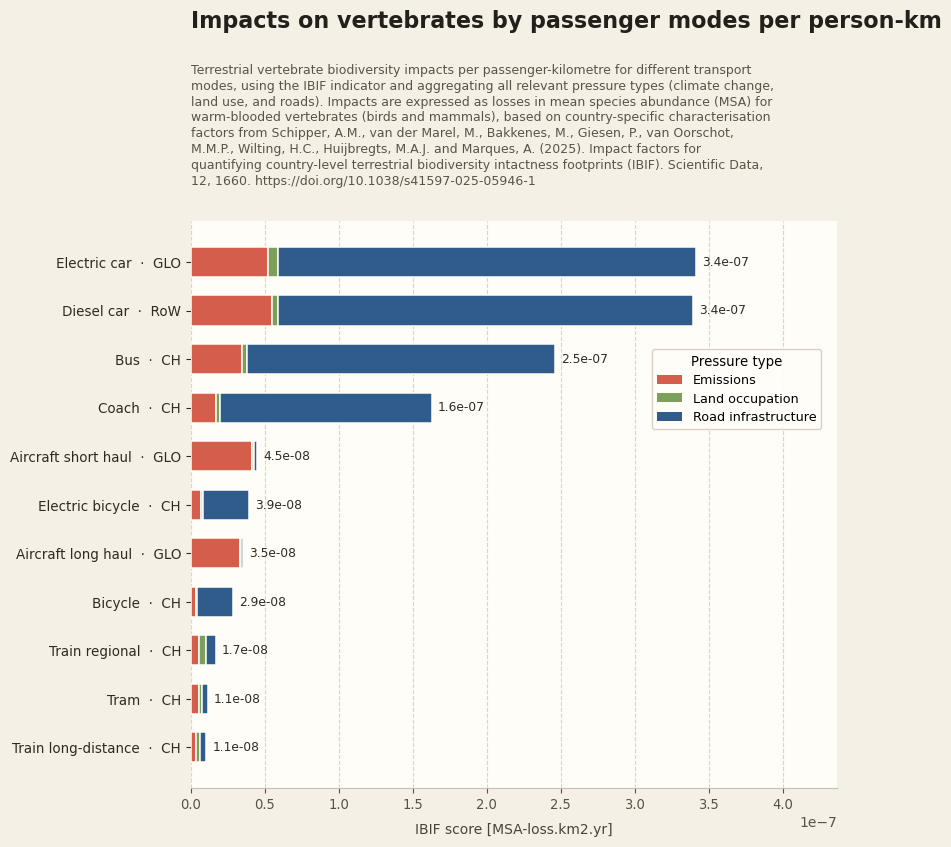

In [13]:
colors = {
    "Emissions": "#D45D4C",
    "Land occupation": "#7BA05B",
    "Road infrastructure": "#2F5C8A",
}

fig, ax = plt.subplots(figsize=(10.6, 9.0))
fig.patch.set_facecolor("#F5F0E6")
ax.set_facecolor("#FFFDF8")

legend_handles = [
    Patch(facecolor=colors[name], edgecolor="none", label=name)
    for name in SUPPLIER_TYPE_ORDER
]

subset = plot_data.copy()
car_rows = subset.index.isin(["Diesel car", "Electric car"])
subset.loc[car_rows, SUPPLIER_TYPE_ORDER] = subset.loc[car_rows, SUPPLIER_TYPE_ORDER] / 1.5
subset["Total"] = subset[SUPPLIER_TYPE_ORDER].sum(axis=1)
labels = [
    f"{idx}  ·  {loc}"
    for idx, loc in zip(subset.index, subset["location"])
]
y = np.arange(len(subset))
left = np.zeros(len(subset))

for supplier_type in SUPPLIER_TYPE_ORDER:
    values = subset[supplier_type].to_numpy()
    ax.barh(
        y,
        values,
        left=left,
        height=0.62,
        color=colors[supplier_type],
        edgecolor="#FFFDF8",
        linewidth=1.1,
    )
    left += values

max_total = subset["Total"].max()
offset = max_total * 0.012
for yy, total in zip(y, subset["Total"]):
    ax.text(
        total + offset,
        yy,
        f"{total:.1e}",
        va="center",
        ha="left",
        fontsize=8.8,
        color="#2F2A24",
    )

ax.set_xlim(0, max_total * 1.28)
ax.set_yticks(y, labels=labels)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", linewidth=0.8, color="#D8D0C3", alpha=0.9)
ax.set_axisbelow(True)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
ax.tick_params(axis="y", labelsize=9.7, colors="#2F2A24")
ax.tick_params(axis="x", labelsize=9.5, colors="#5A5146")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#C8BEAF")
ax.set_xlabel("IBIF score [MSA-loss.km2.yr]", color="#4A433A", labelpad=8)

fig.suptitle(
    "Impacts on vertebrates by passenger modes per person-km",
    x=0.36,
    y=0.965,
    ha="left",
    fontsize=16,
    fontweight="bold",
    color="#231F1A",
)
fig.text(
    0.36,
    0.905,
    "Terrestrial vertebrate biodiversity impacts per passenger-kilometre for different transport\n"
    "modes, using the IBIF indicator and aggregating all relevant pressure types (climate change,\n"
    "land use, and roads). Impacts are expressed as losses in mean species abundance (MSA) for\n"
    "warm-blooded vertebrates (birds and mammals), based on country-specific characterisation\n"
    "factors from Schipper, A.M., van der Marel, M., Bakkenes, M., Giesen, P., van Oorschot,\n"
    "M.M.P., Wilting, H.C., Huijbregts, M.A.J. and Marques, A. (2025). Impact factors for\n"
    "quantifying country-level terrestrial biodiversity intactness footprints (IBIF). Scientific Data,\n"
    "12, 1660. https://doi.org/10.1038/s41597-025-05946-1",
    ha="left",
    va="top",
    fontsize=9,
    color="#5B5348",
    linespacing=1.28,
)
ax.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.985, 0.785),
    frameon=True,
    fancybox=True,
    facecolor="#FFFDF8",
    edgecolor="#D8D0C3",
    framealpha=0.96,
    title="Pressure type",
    title_fontsize=9.6,
    fontsize=9.2,
)

plt.subplots_adjust(top=0.73, left=0.36, right=0.97, bottom=0.1)
plt.savefig("IBIF_transport_modes.png", dpi=300, bbox_inches="tight")
plt.show()

## Optional inspection

The full contribution tables are still available in `detailed_tables`.
For example, the diesel-car activity can be inspected directly to see
the dominant road suppliers and biosphere flows behind its aggregate bar.


In [8]:
detailed_tables["Diesel car"][
    [
        "supplier type",
        "supplier matrix",
        "direction",
        "supplier name",
        "supplier location",
        "impact",
    ]
].sort_values("impact", ascending=False).head(15)


,supplier type,supplier matrix,direction,supplier name,supplier location,impact
20046,Road infrastructure,technosphere,technosphere-technosphere,road construction,RoW,3.817429e-07
13246,Emissions,biosphere,biosphere-technosphere,"Carbon dioxide, fossil",NaN,4.040936e-08
20047,Road infrastructure,technosphere,technosphere-technosphere,"road construction, company, internal",RoW,3.568600e-08
12019,Emissions,biosphere,biosphere-technosphere,"Methane, fossil",NaN,5.643402e-09
15328,Land occupation,biosphere,biosphere-technosphere,"Occupation, traffic area, road network",NaN,3.495872e-09
14502,Emissions,biosphere,biosphere-technosphere,"Carbon dioxide, fossil",NaN,2.828108e-09
20041,Road infrastructure,technosphere,technosphere-technosphere,road construction,CH,2.495483e-09
6691,Emissions,biosphere,biosphere-technosphere,"Carbon dioxide, fossil",NaN,2.361466e-09
13044,Emissions,biosphere,biosphere-technosphere,"Carbon dioxide, fossil",NaN,1.495121e-09
11400,Emissions,biosphere,biosphere-technosphere,"Carbon dioxide, fossil",NaN,1.447478e-09
